In [2]:
# Schizophrenia-Associated Protein Functional Landscape
# Exploratory bioinformatics analysis using UniProt

import requests
import pandas as pd
import matplotlib.pyplot as plt

print("Environment ready!")

Environment ready!


In [3]:
genes = [
    "DRD2",
    "GRIN2A",
    "GRIN2B",
    "NRG1",
    "DISC1",
    "DTNBP1",
    "COMT",
    "CACNA1C",
    "C3",
    "MIR137",
    "SETD1A",
    "SHANK3",
    "DCC",
    "AKT1",
    "ZNF804A"
]

print(f"Number of genes selected: {len(genes)}")
print(genes)

Number of genes selected: 15
['DRD2', 'GRIN2A', 'GRIN2B', 'NRG1', 'DISC1', 'DTNBP1', 'COMT', 'CACNA1C', 'C3', 'MIR137', 'SETD1A', 'SHANK3', 'DCC', 'AKT1', 'ZNF804A']


In [4]:
gene = "DRD2"

url = "https://rest.uniprot.org/uniprotkb/search"

params = {
    "query": f"gene:{gene} AND organism_id:9606 AND reviewed:true",
    "format": "tsv",
    "fields": "accession,id,protein_name,gene_names,organism_name,length"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)
print(response.text[:1000])

Status code: 200
Entry	Entry Name	Protein names	Gene Names	Organism	Length
P14416	DRD2_HUMAN	Dopamine receptor D2 (Dopamine D2 receptor)	DRD2	Homo sapiens (Human)	443



In [5]:
from io import StringIO

data = pd.read_csv(StringIO(response.text), sep="\t")

data

,Entry,Entry Name,Protein names,Gene Names,Organism,Length
0,P14416,DRD2_HUMAN,Dopamine receptor D2 (Dopamine D2 receptor),DRD2,Homo sapiens (Human),443


In [6]:
all_proteins = []

for gene in genes:
    params = {
        "query": f"gene:{gene} AND organism_id:9606 AND reviewed:true",
        "format": "tsv",
        "fields": "accession,id,protein_name,gene_names,organism_name,length"
    }

    response = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params=params
    )

    if response.status_code == 200:
        result = pd.read_csv(StringIO(response.text), sep="\t")

        if not result.empty:
            result["Input_Gene"] = gene
            all_proteins.append(result)

protein_data = pd.concat(all_proteins, ignore_index=True)

print(f"Retrieved {len(protein_data)} protein records.")
protein_data

Retrieved 14 protein records.


,Entry,Entry Name,Protein names,Gene Names,Organism,Length,Input_Gene
0,P14416,DRD2_HUMAN,Dopamine receptor D2 (Dopamine D2 receptor),DRD2,Homo sapiens (Human),443,DRD2
1,Q12879,NMDE1_HUMAN,"Glutamate receptor ionotropic, NMDA 2A (GluN2A...",GRIN2A NMDAR2A,Homo sapiens (Human),1464,GRIN2A
2,Q13224,NMDE2_HUMAN,"Glutamate receptor ionotropic, NMDA 2B (GluN2B...",GRIN2B NMDAR2B,Homo sapiens (Human),1484,GRIN2B
3,Q02297,NRG1_HUMAN,"Pro-neuregulin-1, membrane-bound isoform (Pro-...",NRG1 GGF HGL HRGA NDF SMDF,Homo sapiens (Human),640,NRG1
4,Q9NRI5,DISC1_HUMAN,Disrupted in schizophrenia 1 protein,DISC1 KIAA0457,Homo sapiens (Human),854,DISC1
5,Q96EV8,DTBP1_HUMAN,Dysbindin (Biogenesis of lysosome-related orga...,DTNBP1 BLOC1S8 My031,Homo sapiens (Human),351,DTNBP1
6,P21964,COMT_HUMAN,Catechol O-methyltransferase (EC 2.1.1.6),COMT,Homo sapiens (Human),271,COMT
7,Q13936,CAC1C_HUMAN,Voltage-dependent L-type calcium channel subun...,CACNA1C CACH2 CACN2 CACNL1A1 CCHL1A1,Homo sapiens (Human),2221,CACNA1C
8,P01024,CO3_HUMAN,Complement C3 (C3 and PZP-like alpha-2-macrogl...,C3 CPAMD1,Homo sapiens (Human),1663,C3
9,O15047,SET1A_HUMAN,Histone-lysine N-methyltransferase SETD1A (EC ...,SETD1A KIAA0339 KMT2F SET1 SET1A,Homo sapiens (Human),1707,SETD1A


In [7]:
retrieved_genes = protein_data["Input_Gene"].unique().tolist()

missing_genes = [gene for gene in genes if gene not in retrieved_genes]

print("Retrieved genes:")
print(retrieved_genes)

print("\nMissing genes:")
print(missing_genes)

Retrieved genes:
['DRD2', 'GRIN2A', 'GRIN2B', 'NRG1', 'DISC1', 'DTNBP1', 'COMT', 'CACNA1C', 'C3', 'SETD1A', 'SHANK3', 'DCC', 'AKT1', 'ZNF804A']

Missing genes:
['MIR137']


In [8]:
protein_data[["Input_Gene", "Entry", "Protein names", "Length"]]

,Input_Gene,Entry,Protein names,Length
0,DRD2,P14416,Dopamine receptor D2 (Dopamine D2 receptor),443
1,GRIN2A,Q12879,"Glutamate receptor ionotropic, NMDA 2A (GluN2A...",1464
2,GRIN2B,Q13224,"Glutamate receptor ionotropic, NMDA 2B (GluN2B...",1484
3,NRG1,Q02297,"Pro-neuregulin-1, membrane-bound isoform (Pro-...",640
4,DISC1,Q9NRI5,Disrupted in schizophrenia 1 protein,854
5,DTNBP1,Q96EV8,Dysbindin (Biogenesis of lysosome-related orga...,351
6,COMT,P21964,Catechol O-methyltransferase (EC 2.1.1.6),271
7,CACNA1C,Q13936,Voltage-dependent L-type calcium channel subun...,2221
8,C3,P01024,Complement C3 (C3 and PZP-like alpha-2-macrogl...,1663
9,SETD1A,O15047,Histone-lysine N-methyltransferase SETD1A (EC ...,1707


In [9]:
# Retrieve richer functional annotations from UniProt

all_proteins = []

for gene in genes:
    params = {
        "query": f"gene:{gene} AND organism_id:9606 AND reviewed:true",
        "format": "tsv",
        "fields": (
            "accession,"
            "id,"
            "protein_name,"
            "gene_names,"
            "organism_name,"
            "length,"
            "cc_function,"
            "cc_subcellular_location,"
            "keyword"
        )
    }

    response = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params=params
    )

    if response.status_code == 200:
        result = pd.read_csv(StringIO(response.text), sep="\t")

        if not result.empty:
            result["Input_Gene"] = gene
            all_proteins.append(result)

protein_data = pd.concat(all_proteins, ignore_index=True)

print(f"Retrieved {len(protein_data)} protein records.")
print(f"Number of columns: {len(protein_data.columns)}")

protein_data.head()

Retrieved 14 protein records.
Number of columns: 10


,Entry,Entry Name,Protein names,Gene Names,Organism,Length,Function [CC],Subcellular location [CC],Keywords,Input_Gene
0,P14416,DRD2_HUMAN,Dopamine receptor D2 (Dopamine D2 receptor),DRD2,Homo sapiens (Human),443,FUNCTION: G protein-coupled receptor for dopam...,SUBCELLULAR LOCATION: Postsynaptic cell membra...,3D-structure;Alternative splicing;Cell membran...,DRD2
1,Q12879,NMDE1_HUMAN,"Glutamate receptor ionotropic, NMDA 2A (GluN2A...",GRIN2A NMDAR2A,Homo sapiens (Human),1464,FUNCTION: Component of N-methyl-D-aspartate (N...,"SUBCELLULAR LOCATION: Cell projection, dendrit...",3D-structure;Alternative splicing;Calcium;Cell...,GRIN2A
2,Q13224,NMDE2_HUMAN,"Glutamate receptor ionotropic, NMDA 2B (GluN2B...",GRIN2B NMDAR2B,Homo sapiens (Human),1484,FUNCTION: Component of N-methyl-D-aspartate (N...,SUBCELLULAR LOCATION: Cell membrane {ECO:00002...,3D-structure;Calcium;Cell membrane;Cell projec...,GRIN2B
3,Q02297,NRG1_HUMAN,"Pro-neuregulin-1, membrane-bound isoform (Pro-...",NRG1 GGF HGL HRGA NDF SMDF,Homo sapiens (Human),640,FUNCTION: Direct ligand for ERBB3 and ERBB4 ty...,"SUBCELLULAR LOCATION: [Pro-neuregulin-1, membr...",3D-structure;Alternative splicing;Cell membran...,NRG1
4,Q9NRI5,DISC1_HUMAN,Disrupted in schizophrenia 1 protein,DISC1 KIAA0457,Homo sapiens (Human),854,FUNCTION: Involved in the regulation of multip...,SUBCELLULAR LOCATION: Cytoplasm {ECO:0000269|P...,3D-structure;Alternative splicing;Chromosomal ...,DISC1


In [10]:
protein_data.columns.tolist()

['Entry',
 'Entry Name',
 'Protein names',
 'Gene Names',
 'Organism',
 'Length',
 'Function [CC]',
 'Subcellular location [CC]',
 'Keywords',
 'Input_Gene']

In [11]:
protein_data[[
    "Input_Gene",
    "Entry",
    "Protein names",
    "Length",
    "Function",
    "Subcellular location",
    "Keywords"
]]

KeyError: "['Function', 'Subcellular location'] not in index"

In [12]:
print(protein_data.columns.tolist())

['Entry', 'Entry Name', 'Protein names', 'Gene Names', 'Organism', 'Length', 'Function [CC]', 'Subcellular location [CC]', 'Keywords', 'Input_Gene']


In [13]:
protein_data[[
    "Input_Gene",
    "Entry",
    "Protein names",
    "Length",
    "Function [CC]",
    "Subcellular location [CC]",
    "Keywords"
]]

,Input_Gene,Entry,Protein names,Length,Function [CC],Subcellular location [CC],Keywords
0,DRD2,P14416,Dopamine receptor D2 (Dopamine D2 receptor),443,FUNCTION: G protein-coupled receptor for dopam...,SUBCELLULAR LOCATION: Postsynaptic cell membra...,3D-structure;Alternative splicing;Cell membran...
1,GRIN2A,Q12879,"Glutamate receptor ionotropic, NMDA 2A (GluN2A...",1464,FUNCTION: Component of N-methyl-D-aspartate (N...,"SUBCELLULAR LOCATION: Cell projection, dendrit...",3D-structure;Alternative splicing;Calcium;Cell...
2,GRIN2B,Q13224,"Glutamate receptor ionotropic, NMDA 2B (GluN2B...",1484,FUNCTION: Component of N-methyl-D-aspartate (N...,SUBCELLULAR LOCATION: Cell membrane {ECO:00002...,3D-structure;Calcium;Cell membrane;Cell projec...
3,NRG1,Q02297,"Pro-neuregulin-1, membrane-bound isoform (Pro-...",640,FUNCTION: Direct ligand for ERBB3 and ERBB4 ty...,"SUBCELLULAR LOCATION: [Pro-neuregulin-1, membr...",3D-structure;Alternative splicing;Cell membran...
4,DISC1,Q9NRI5,Disrupted in schizophrenia 1 protein,854,FUNCTION: Involved in the regulation of multip...,SUBCELLULAR LOCATION: Cytoplasm {ECO:0000269|P...,3D-structure;Alternative splicing;Chromosomal ...
5,DTNBP1,Q96EV8,Dysbindin (Biogenesis of lysosome-related orga...,351,"FUNCTION: Component of the BLOC-1 complex, a c...",SUBCELLULAR LOCATION: [Isoform 1]: Cytoplasm {...,Albinism;Alternative initiation;Alternative sp...
6,COMT,P21964,Catechol O-methyltransferase (EC 2.1.1.6),271,"FUNCTION: Catalyzes the O-methylation, and the...",SUBCELLULAR LOCATION: [Isoform Soluble]: Cytop...,3D-structure;Alternative initiation;Catecholam...
7,CACNA1C,Q13936,Voltage-dependent L-type calcium channel subun...,2221,"FUNCTION: Pore-forming, alpha-1C subunit of th...",SUBCELLULAR LOCATION: Cell membrane {ECO:00002...,3D-structure;Alternative splicing;Autism;Autis...
8,C3,P01024,Complement C3 (C3 and PZP-like alpha-2-macrogl...,1663,FUNCTION: Precursor of non-enzymatic component...,SUBCELLULAR LOCATION: Secreted {ECO:0000269|Pu...,3D-structure;Age-related macular degeneration;...
9,SETD1A,O15047,Histone-lysine N-methyltransferase SETD1A (EC ...,1707,FUNCTION: Histone methyltransferase that catal...,SUBCELLULAR LOCATION: Nucleus speckle {ECO:000...,3D-structure;Activator;Chromatin regulator;Chr...


In [14]:
protein_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Entry                      14 non-null     object
 1   Entry Name                 14 non-null     object
 2   Protein names              14 non-null     object
 3   Gene Names                 14 non-null     object
 4   Organism                   14 non-null     object
 5   Length                     14 non-null     int64 
 6   Function [CC]              13 non-null     object
 7   Subcellular location [CC]  13 non-null     object
 8   Keywords                   14 non-null     object
 9   Input_Gene                 14 non-null     object
dtypes: int64(1), object(9)
memory usage: 1.2+ KB


In [15]:
analysis_data = protein_data.rename(columns={
    "Input_Gene": "Gene",
    "Entry": "UniProt_ID",
    "Entry Name": "UniProt_Name",
    "Protein names": "Protein_Name",
    "Gene Names": "Gene_Names",
    "Organism": "Organism",
    "Length": "Protein_Length",
    "Function [CC]": "Function",
    "Subcellular location [CC]": "Subcellular_Location",
    "Keywords": "Keywords"
})

analysis_data = analysis_data[[
    "Gene",
    "UniProt_ID",
    "Protein_Name",
    "Protein_Length",
    "Function",
    "Subcellular_Location",
    "Keywords"
]]

analysis_data.head()

,Gene,UniProt_ID,Protein_Name,Protein_Length,Function,Subcellular_Location,Keywords
0,DRD2,P14416,Dopamine receptor D2 (Dopamine D2 receptor),443,FUNCTION: G protein-coupled receptor for dopam...,SUBCELLULAR LOCATION: Postsynaptic cell membra...,3D-structure;Alternative splicing;Cell membran...
1,GRIN2A,Q12879,"Glutamate receptor ionotropic, NMDA 2A (GluN2A...",1464,FUNCTION: Component of N-methyl-D-aspartate (N...,"SUBCELLULAR LOCATION: Cell projection, dendrit...",3D-structure;Alternative splicing;Calcium;Cell...
2,GRIN2B,Q13224,"Glutamate receptor ionotropic, NMDA 2B (GluN2B...",1484,FUNCTION: Component of N-methyl-D-aspartate (N...,SUBCELLULAR LOCATION: Cell membrane {ECO:00002...,3D-structure;Calcium;Cell membrane;Cell projec...
3,NRG1,Q02297,"Pro-neuregulin-1, membrane-bound isoform (Pro-...",640,FUNCTION: Direct ligand for ERBB3 and ERBB4 ty...,"SUBCELLULAR LOCATION: [Pro-neuregulin-1, membr...",3D-structure;Alternative splicing;Cell membran...
4,DISC1,Q9NRI5,Disrupted in schizophrenia 1 protein,854,FUNCTION: Involved in the regulation of multip...,SUBCELLULAR LOCATION: Cytoplasm {ECO:0000269|P...,3D-structure;Alternative splicing;Chromosomal ...


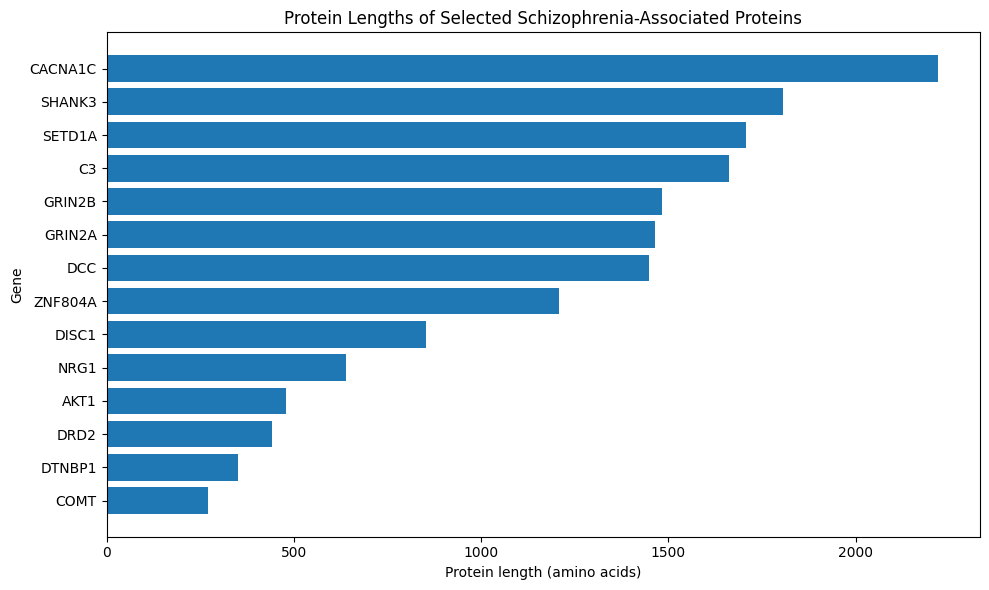

In [46]:
plt.figure(figsize=(10, 6))

sorted_data = analysis_data.sort_values("Protein_Length")

plt.barh(
    sorted_data["Gene"],
    sorted_data["Protein_Length"]
)

plt.xlabel("Protein length (amino acids)")
plt.ylabel("Gene")
plt.title("Protein Lengths of Selected Schizophrenia-Associated Proteins")

plt.tight_layout()
plt.savefig("protein_lengths.png", dpi=300, bbox_inches="tight")
plt.show()

,Protein_Length
count,14.000000
mean,1145.714286
std,630.011408
min,271.000000
25%,520.000000
50%,1328.000000
75%,1618.250000
max,2221.000000


In [18]:
print("Shortest protein:")
print(
    analysis_data.loc[
        analysis_data["Protein_Length"].idxmin(),
        ["Gene", "Protein_Length"]
    ]
)

print("\nLongest protein:")
print(
    analysis_data.loc[
        analysis_data["Protein_Length"].idxmax(),
        ["Gene", "Protein_Length"]
    ]
)

Shortest protein:
Gene              COMT
Protein_Length     271
Name: 6, dtype: object

Longest protein:
Gene              CACNA1C
Protein_Length       2221
Name: 7, dtype: object


In [19]:
def classify_localization(text):
    text = str(text).lower()

    categories = []

    if "membrane" in text:
        categories.append("Cell membrane")

    if "cytoplasm" in text or "cytosol" in text:
        categories.append("Cytoplasm")

    if "nucleus" in text or "nuclear" in text:
        categories.append("Nucleus")

    if "extracellular" in text or "secreted" in text:
        categories.append("Extracellular")

    if not categories:
        categories.append("Other")

    return categories


analysis_data["Localization_Category"] = (
    analysis_data["Subcellular_Location"]
    .apply(classify_localization)
)

analysis_data[[
    "Gene",
    "Subcellular_Location",
    "Localization_Category"
]]

,Gene,Subcellular_Location,Localization_Category
0,DRD2,SUBCELLULAR LOCATION: Postsynaptic cell membra...,[Cell membrane]
1,GRIN2A,"SUBCELLULAR LOCATION: Cell projection, dendrit...","[Cell membrane, Cytoplasm]"
2,GRIN2B,SUBCELLULAR LOCATION: Cell membrane {ECO:00002...,"[Cell membrane, Cytoplasm]"
3,NRG1,"SUBCELLULAR LOCATION: [Pro-neuregulin-1, membr...","[Cell membrane, Nucleus, Extracellular]"
4,DISC1,SUBCELLULAR LOCATION: Cytoplasm {ECO:0000269|P...,"[Cytoplasm, Nucleus]"
5,DTNBP1,SUBCELLULAR LOCATION: [Isoform 1]: Cytoplasm {...,"[Cell membrane, Cytoplasm, Nucleus]"
6,COMT,SUBCELLULAR LOCATION: [Isoform Soluble]: Cytop...,"[Cell membrane, Cytoplasm, Extracellular]"
7,CACNA1C,SUBCELLULAR LOCATION: Cell membrane {ECO:00002...,[Cell membrane]
8,C3,SUBCELLULAR LOCATION: Secreted {ECO:0000269|Pu...,[Extracellular]
9,SETD1A,SUBCELLULAR LOCATION: Nucleus speckle {ECO:000...,"[Cytoplasm, Nucleus]"


In [20]:
from collections import Counter

localization_counts = Counter()

for categories in analysis_data["Localization_Category"]:
    for category in categories:
        localization_counts[category] += 1

localization_counts

Counter({'Cell membrane': 9,
         'Cytoplasm': 8,
         'Nucleus': 5,
         'Extracellular': 3,
         'Other': 1})

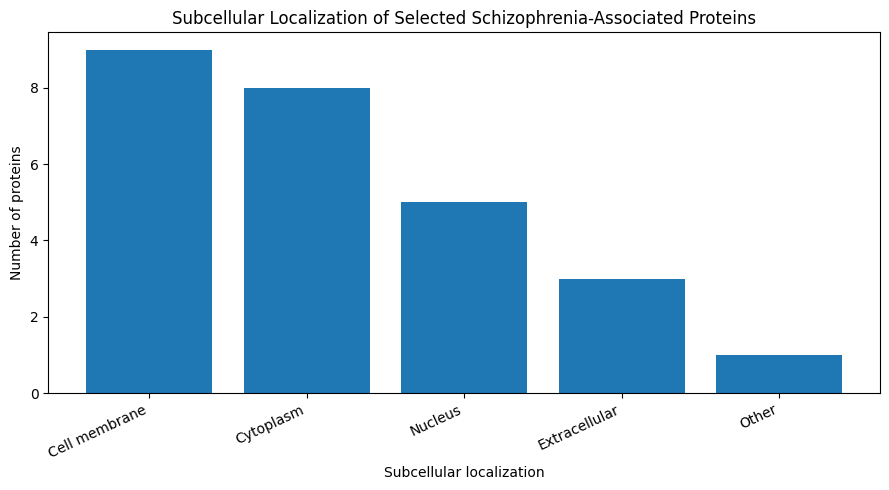

In [47]:
localization_df = pd.DataFrame(
    localization_counts.items(),
    columns=["Localization", "Protein_Count"]
).sort_values(
    "Protein_Count",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    localization_df["Localization"],
    localization_df["Protein_Count"]
)

plt.xlabel("Subcellular localization")
plt.ylabel("Number of proteins")
plt.title(
    "Subcellular Localization of Selected "
    "Schizophrenia-Associated Proteins"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("subcellular_localization.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
function_keywords = {
    "Neurotransmitter / receptor signaling": [
        "receptor",
        "neurotransmitter",
        "dopamine",
        "glutamate"
    ],

    "Ion channel / calcium signaling": [
        "ion channel",
        "calcium channel",
        "calcium"
    ],

    "Kinase / phosphorylation": [
        "kinase",
        "phosphorylation",
        "phosphorylate"
    ],

    "Gene regulation / chromatin": [
        "transcription",
        "chromatin",
        "histone",
        "methyltransferase"
    ],

    "Cell adhesion / development": [
        "cell adhesion",
        "axon",
        "neuronal development",
        "development"
    ]
}

In [24]:
function_counts = {}

for category, keywords in function_keywords.items():
    count = 0

    for function in analysis_data["Function"]:
        text = str(function).lower()

        if any(keyword in text for keyword in keywords):
            count += 1

    function_counts[category] = count

function_counts

{'Neurotransmitter / receptor signaling': 11,
 'Ion channel / calcium signaling': 4,
 'Kinase / phosphorylation': 5,
 'Gene regulation / chromatin': 3,
 'Cell adhesion / development': 6}

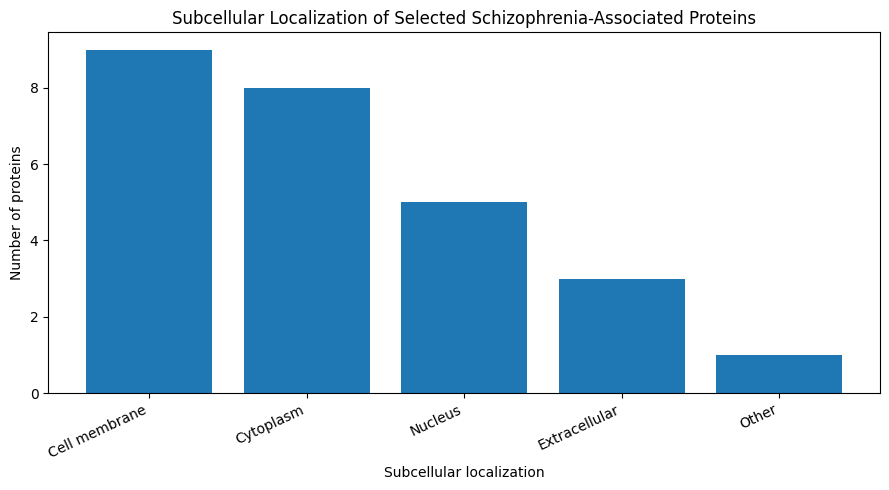

In [26]:
localization_df = pd.DataFrame(
    localization_counts.items(),
    columns=["Localization", "Protein_Count"]
).sort_values(
    "Protein_Count",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    localization_df["Localization"],
    localization_df["Protein_Count"]
)

plt.xlabel("Subcellular localization")
plt.ylabel("Number of proteins")
plt.title(
    "Subcellular Localization of Selected "
    "Schizophrenia-Associated Proteins"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [27]:
for _, row in analysis_data.iterrows():
    print("=" * 80)
    print(row["Gene"])
    print(row["Function"])

DRD2
FUNCTION: G protein-coupled receptor for dopamine, a catecholamine neurotransmitter hormone that functions as the brain's 'reward chemical', driving motivation, reinforcement learning and pleasure (PubMed:21645528, PubMed:32103023, PubMed:32528175, PubMed:33353947, PubMed:33571431, PubMed:37221270, PubMed:39103320). Dopamine binding causes a conformation change that triggers signaling via guanine nucleotide-binding proteins (G proteins) and modulates the activity of downstream effectors, such as adenylate cyclase (PubMed:32103023, PubMed:32528175, PubMed:33353947, PubMed:33571431, PubMed:37221270). Dopamine receptors can be classified in two categories: (1) DRD2 (together with DRD3 and DRD4) is a D2-type receptor and is coupled to G(i)/G(o) G proteins, mediating inhibition of adenylate cyclase activity, while D1-type receptors (DRD1 and DRD5) are coupled to G(s) G proteins and promote activation of adenylate cyclase activity (PubMed:32103023, PubMed:32528175, PubMed:33353947, PubM

In [37]:
# Primary functional category based on UniProt function descriptions

primary_function = {
    "DRD2": "Dopamine receptor signaling",
    "GRIN2A": "Glutamate receptor / ion channel",
    "GRIN2B": "Glutamate receptor / ion channel",
    "NRG1": "Growth factor signaling",
    "DISC1": "Neurodevelopment / signaling",
    "DTNBP1": "Synaptic vesicle trafficking",
    "COMT": "Catecholamine metabolism",
    "CACNA1C": "Calcium ion channel",
    "C3": "Complement / immune signaling",
    "SETD1A": "Chromatin regulation",
    "SHANK3": "Synaptic structure / signaling",
    "DCC": "Axon guidance / neuronal development",
    "AKT1": "Protein kinase signaling",
    "ZNF804A": "Unclassified"
}

analysis_data["Primary_Function"] = (
    analysis_data["Gene"].map(primary_function)
)

analysis_data[[
    "Gene",
    "Primary_Function"
]]

,Gene,Primary_Function
0,DRD2,Dopamine receptor signaling
1,GRIN2A,Glutamate receptor / ion channel
2,GRIN2B,Glutamate receptor / ion channel
3,NRG1,Growth factor signaling
4,DISC1,Neurodevelopment / signaling
5,DTNBP1,Synaptic vesicle trafficking
6,COMT,Catecholamine metabolism
7,CACNA1C,Calcium ion channel
8,C3,Complement / immune signaling
9,SETD1A,Chromatin regulation


In [38]:
function_counts = (
    analysis_data["Primary_Function"]
    .value_counts()
)

print(function_counts)

Primary_Function
Glutamate receptor / ion channel        2
Dopamine receptor signaling             1
Growth factor signaling                 1
Neurodevelopment / signaling            1
Synaptic vesicle trafficking            1
Catecholamine metabolism                1
Calcium ion channel                     1
Complement / immune signaling           1
Chromatin regulation                    1
Synaptic structure / signaling          1
Axon guidance / neuronal development    1
Protein kinase signaling                1
Unclassified                            1
Name: count, dtype: int64


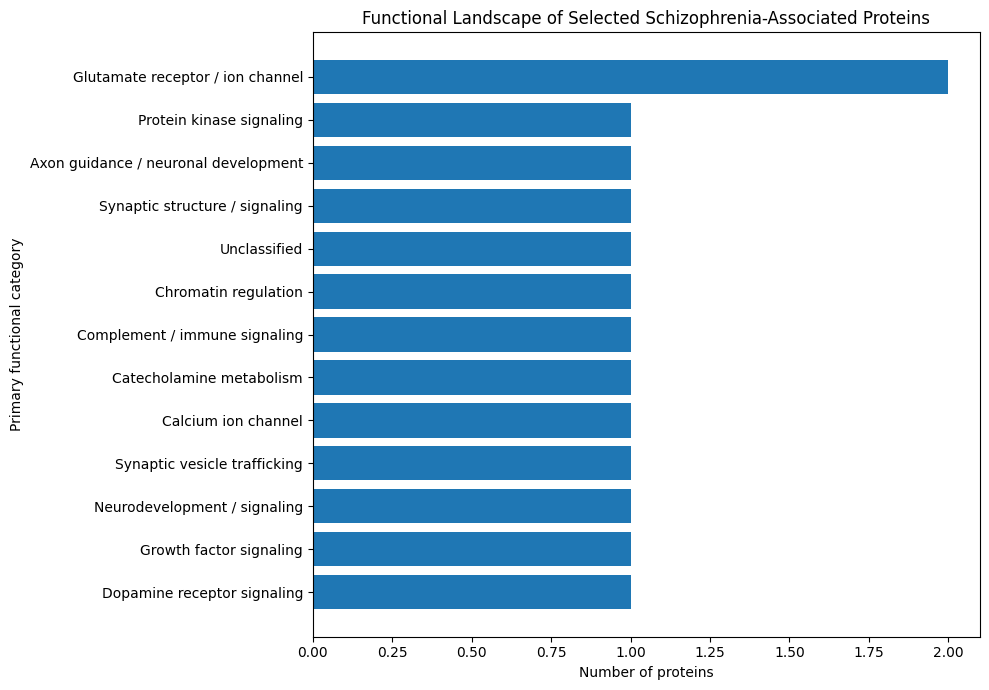

In [48]:
function_df = (
    function_counts
    .rename_axis("Functional_Category")
    .reset_index(name="Protein_Count")
    .sort_values("Protein_Count", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    function_df["Functional_Category"],
    function_df["Protein_Count"]
)

plt.xlabel("Number of proteins")
plt.ylabel("Primary functional category")
plt.title(
    "Functional Landscape of Selected "
    "Schizophrenia-Associated Proteins"
)

plt.tight_layout()
plt.savefig("functional_landscape.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
analysis_data["Protein_Length_kDa_Approx"] = (
    analysis_data["Protein_Length"] * 0.11
)

analysis_data[[
    "Gene",
    "UniProt_ID",
    "Protein_Length",
    "Protein_Length_kDa_Approx",
    "Primary_Function"
]]

,Gene,UniProt_ID,Protein_Length,Protein_Length_kDa_Approx,Primary_Function
0,DRD2,P14416,443,48.73,Dopamine receptor signaling
1,GRIN2A,Q12879,1464,161.04,Glutamate receptor / ion channel
2,GRIN2B,Q13224,1484,163.24,Glutamate receptor / ion channel
3,NRG1,Q02297,640,70.40,Growth factor signaling
4,DISC1,Q9NRI5,854,93.94,Neurodevelopment / signaling
5,DTNBP1,Q96EV8,351,38.61,Synaptic vesicle trafficking
6,COMT,P21964,271,29.81,Catecholamine metabolism
7,CACNA1C,Q13936,2221,244.31,Calcium ion channel
8,C3,P01024,1663,182.93,Complement / immune signaling
9,SETD1A,O15047,1707,187.77,Chromatin regulation


In [41]:
print("Number of proteins:", len(analysis_data))
print("Mean protein length:", round(analysis_data["Protein_Length"].mean(), 1), "aa")
print("Median protein length:", int(analysis_data["Protein_Length"].median()), "aa")
print("Shortest protein:", analysis_data.loc[
    analysis_data["Protein_Length"].idxmin(), "Gene"
])
print("Longest protein:", analysis_data.loc[
    analysis_data["Protein_Length"].idxmax(), "Gene"
])
print("Missing function annotations:", analysis_data["Function"].isna().sum())

Number of proteins: 14
Mean protein length: 1145.7 aa
Median protein length: 1328 aa
Shortest protein: COMT
Longest protein: CACNA1C
Missing function annotations: 1


In [42]:
final_data = analysis_data[[
    "Gene",
    "UniProt_ID",
    "Protein_Name",
    "Protein_Length",
    "Protein_Length_kDa_Approx",
    "Primary_Function",
    "Subcellular_Location"
]].copy()

final_data.to_csv(
    "schizophrenia_protein_landscape.csv",
    index=False
)

print("Final dataset saved!")
print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))

Final dataset saved!
Rows: 14
Columns: 7


In [43]:
from google.colab import files

files.download("schizophrenia_protein_landscape.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
def identify_functional_themes(function_text):
    text = str(function_text).lower()
    matched = []

    for category, keywords in function_keywords.items():
        if any(keyword in text for keyword in keywords):
            matched.append(category)

    return matched


analysis_data["Functional_Themes"] = (
    analysis_data["Function"]
    .apply(identify_functional_themes)
)

analysis_data["Number_of_Functional_Themes"] = (
    analysis_data["Functional_Themes"].apply(len)
)

analysis_data[[
    "Gene",
    "Functional_Themes"
]]

,Gene,Functional_Themes
0,DRD2,[Neurotransmitter / receptor signaling]
1,GRIN2A,"[Neurotransmitter / receptor signaling, Ion ch..."
2,GRIN2B,"[Neurotransmitter / receptor signaling, Ion ch..."
3,NRG1,"[Neurotransmitter / receptor signaling, Kinase..."
4,DISC1,"[Gene regulation / chromatin, Cell adhesion / ..."
5,DTNBP1,"[Neurotransmitter / receptor signaling, Kinase..."
6,COMT,[Neurotransmitter / receptor signaling]
7,CACNA1C,"[Neurotransmitter / receptor signaling, Ion ch..."
8,C3,"[Neurotransmitter / receptor signaling, Kinase..."
9,SETD1A,[Gene regulation / chromatin]


In [35]:
analysis_data[[
    "Gene",
    "Function"
]].to_string(index=False)

"   Gene                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [36]:
for _, row in analysis_data.iterrows():
    print(f"\n--- {row['Gene']} ---")
    print(row["Function"])


--- DRD2 ---
FUNCTION: G protein-coupled receptor for dopamine, a catecholamine neurotransmitter hormone that functions as the brain's 'reward chemical', driving motivation, reinforcement learning and pleasure (PubMed:21645528, PubMed:32103023, PubMed:32528175, PubMed:33353947, PubMed:33571431, PubMed:37221270, PubMed:39103320). Dopamine binding causes a conformation change that triggers signaling via guanine nucleotide-binding proteins (G proteins) and modulates the activity of downstream effectors, such as adenylate cyclase (PubMed:32103023, PubMed:32528175, PubMed:33353947, PubMed:33571431, PubMed:37221270). Dopamine receptors can be classified in two categories: (1) DRD2 (together with DRD3 and DRD4) is a D2-type receptor and is coupled to G(i)/G(o) G proteins, mediating inhibition of adenylate cyclase activity, while D1-type receptors (DRD1 and DRD5) are coupled to G(s) G proteins and promote activation of adenylate cyclase activity (PubMed:32103023, PubMed:32528175, PubMed:33353

In [29]:
function_counts = {}

for category, keywords in function_keywords.items():
    count = 0

    for function in analysis_data["Function"]:
        text = str(function).lower()

        if any(keyword in text for keyword in keywords):
            count += 1

    function_counts[category] = count

print(function_counts)

{'Neurotransmitter / receptor signaling': 11, 'Ion channel / calcium signaling': 4, 'Kinase / phosphorylation': 5, 'Gene regulation / chromatin': 3, 'Cell adhesion / development': 6}


In [30]:
def identify_functional_themes(function_text):
    text = str(function_text).lower()
    matched = []

    for category, keywords in function_keywords.items():
        if any(keyword in text for keyword in keywords):
            matched.append(category)

    return matched


analysis_data["Functional_Themes"] = (
    analysis_data["Function"]
    .apply(identify_functional_themes)
)

analysis_data[[
    "Gene",
    "Protein_Length",
    "Localization_Category",
    "Functional_Themes"
]]

,Gene,Protein_Length,Localization_Category,Functional_Themes
0,DRD2,443,[Cell membrane],[Neurotransmitter / receptor signaling]
1,GRIN2A,1464,"[Cell membrane, Cytoplasm]","[Neurotransmitter / receptor signaling, Ion ch..."
2,GRIN2B,1484,"[Cell membrane, Cytoplasm]","[Neurotransmitter / receptor signaling, Ion ch..."
3,NRG1,640,"[Cell membrane, Nucleus, Extracellular]","[Neurotransmitter / receptor signaling, Kinase..."
4,DISC1,854,"[Cytoplasm, Nucleus]","[Gene regulation / chromatin, Cell adhesion / ..."
5,DTNBP1,351,"[Cell membrane, Cytoplasm, Nucleus]","[Neurotransmitter / receptor signaling, Kinase..."
6,COMT,271,"[Cell membrane, Cytoplasm, Extracellular]",[Neurotransmitter / receptor signaling]
7,CACNA1C,2221,[Cell membrane],"[Neurotransmitter / receptor signaling, Ion ch..."
8,C3,1663,[Extracellular],"[Neurotransmitter / receptor signaling, Kinase..."
9,SETD1A,1707,"[Cytoplasm, Nucleus]",[Gene regulation / chromatin]


In [31]:
analysis_data["Number_of_Functional_Themes"] = (
    analysis_data["Functional_Themes"].apply(len)
)

analysis_data[[
    "Gene",
    "Protein_Length",
    "Number_of_Functional_Themes",
    "Functional_Themes"
]].sort_values(
    "Number_of_Functional_Themes",
    ascending=False
)

,Gene,Protein_Length,Number_of_Functional_Themes,Functional_Themes
12,AKT1,480,5,"[Neurotransmitter / receptor signaling, Ion ch..."
3,NRG1,640,3,"[Neurotransmitter / receptor signaling, Kinase..."
7,CACNA1C,2221,3,"[Neurotransmitter / receptor signaling, Ion ch..."
8,C3,1663,3,"[Neurotransmitter / receptor signaling, Kinase..."
2,GRIN2B,1484,3,"[Neurotransmitter / receptor signaling, Ion ch..."
4,DISC1,854,2,"[Gene regulation / chromatin, Cell adhesion / ..."
1,GRIN2A,1464,2,"[Neurotransmitter / receptor signaling, Ion ch..."
5,DTNBP1,351,2,"[Neurotransmitter / receptor signaling, Kinase..."
11,DCC,1447,2,"[Neurotransmitter / receptor signaling, Cell a..."
0,DRD2,443,1,[Neurotransmitter / receptor signaling]


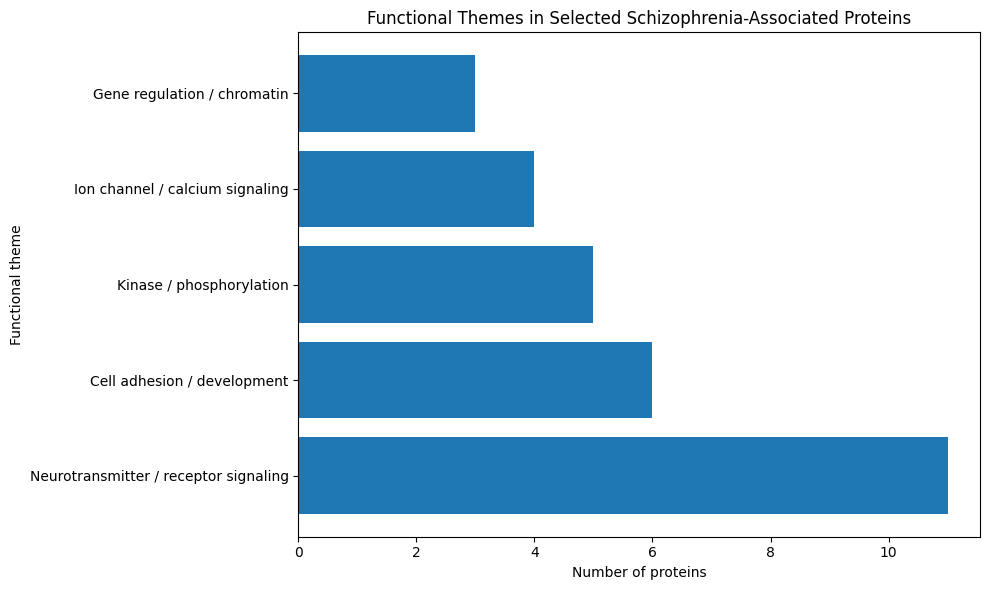

In [32]:
function_df = pd.DataFrame(
    function_counts.items(),
    columns=["Functional_Theme", "Protein_Count"]
).sort_values(
    "Protein_Count",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    function_df["Functional_Theme"],
    function_df["Protein_Count"]
)

plt.xlabel("Number of proteins")
plt.ylabel("Functional theme")
plt.title(
    "Functional Themes in Selected "
    "Schizophrenia-Associated Proteins"
)

plt.tight_layout()
plt.show()

In [33]:
analysis_data[[
    "Gene",
    "Protein_Length",
    "Number_of_Functional_Themes",
    "Functional_Themes"
]].sort_values(
    "Number_of_Functional_Themes",
    ascending=False
)

,Gene,Protein_Length,Number_of_Functional_Themes,Functional_Themes
12,AKT1,480,5,"[Neurotransmitter / receptor signaling, Ion ch..."
3,NRG1,640,3,"[Neurotransmitter / receptor signaling, Kinase..."
7,CACNA1C,2221,3,"[Neurotransmitter / receptor signaling, Ion ch..."
8,C3,1663,3,"[Neurotransmitter / receptor signaling, Kinase..."
2,GRIN2B,1484,3,"[Neurotransmitter / receptor signaling, Ion ch..."
4,DISC1,854,2,"[Gene regulation / chromatin, Cell adhesion / ..."
1,GRIN2A,1464,2,"[Neurotransmitter / receptor signaling, Ion ch..."
5,DTNBP1,351,2,"[Neurotransmitter / receptor signaling, Kinase..."
11,DCC,1447,2,"[Neurotransmitter / receptor signaling, Cell a..."
0,DRD2,443,1,[Neurotransmitter / receptor signaling]


In [49]:
import os

files_to_check = [
    "schizophrenia_protein_landscape.csv",
    "protein_lengths.png",
    "subcellular_localization.png",
    "functional_landscape.png"
]

for filename in files_to_check:
    print(filename, "→", "✓ Found" if os.path.exists(filename) else "✗ Missing")

schizophrenia_protein_landscape.csv → ✓ Found
protein_lengths.png → ✓ Found
subcellular_localization.png → ✓ Found
functional_landscape.png → ✓ Found


In [50]:
import os

project_folders = [
    "schizophrenia-protein-landscape",
    "schizophrenia-protein-landscape/data",
    "schizophrenia-protein-landscape/figures"
]

for folder in project_folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created!")

Project folders created!


In [51]:
import shutil

shutil.copy(
    "schizophrenia_protein_landscape.csv",
    "schizophrenia-protein-landscape/data/schizophrenia_protein_landscape.csv"
)

print("Dataset copied to project/data/")

Dataset copied to project/data/


In [52]:
final_data.to_csv(
    "schizophrenia_protein_landscape.csv",
    index=False
)

import shutil

shutil.copy(
    "schizophrenia_protein_landscape.csv",
    "schizophrenia-protein-landscape/data/schizophrenia_protein_landscape.csv"
)

print("Dataset copied to project/data/")

Dataset copied to project/data/


In [53]:
import shutil

figure_files = [
    "protein_lengths.png",
    "subcellular_localization.png",
    "functional_landscape.png"
]

for filename in figure_files:
    shutil.copy(
        filename,
        f"schizophrenia-protein-landscape/figures/{filename}"
    )

print("All figures copied to project/figures/")

All figures copied to project/figures/


In [54]:
readme = """
# Functional Landscape of Schizophrenia-Associated Proteins

## Overview

This project explores the functional and molecular characteristics of a selected set of proteins associated with schizophrenia using data retrieved programmatically from UniProt.

The analysis examines protein length, subcellular localization, and broad primary functional categories to visualize the biological diversity represented within the selected protein set.

## Research Question

What functional and molecular characteristics are shared among proteins associated with schizophrenia?

## Dataset

The initial analysis included 15 selected schizophrenia-associated genes.

UniProt reviewed human protein records were retrieved using the UniProt REST API.

14 protein records were successfully retrieved.

MIR137 was excluded because it did not map to a reviewed human protein record in the protein-level UniProt query.

## Analysis

The project includes:

- Retrieval of reviewed human protein records from UniProt
- Protein length analysis
- Approximate molecular-weight estimation from protein length
- Subcellular localization classification
- Manual primary functional categorization based on UniProt function descriptions
- Visualization of functional and molecular characteristics

## Key Observations

- The analyzed proteins show substantial variation in protein length.
- Protein lengths range from 271 amino acids to 2,221 amino acids.
- The selected proteins span diverse biological roles, including neurotransmitter signaling, ion-channel activity, synaptic biology, chromatin regulation, neuronal development, kinase signaling, metabolism, and immune signaling.
- Glutamate receptor / ion channel function is represented by two proteins in the selected set.
- ZNF804A was retained in the dataset but left unclassified because no function annotation was available in the retrieved UniProt record.

## Figures

### Protein Lengths

![Protein lengths](figures/protein_lengths.png)

### Subcellular Localization

![Subcellular localization](figures/subcellular_localization.png)

### Functional Landscape

![Functional landscape](figures/functional_landscape.png)

## Limitations

This is an exploratory analysis of a small, manually selected set of schizophrenia-associated proteins. The results should not be interpreted as demonstrating statistical enrichment or causality.

The functional categories are broad, manually assigned categories based on UniProt function descriptions rather than results from formal pathway-enrichment analysis.

Subcellular localization categories may overlap because a protein can occur in multiple cellular compartments.

MIR137 was excluded from the protein-level analysis because it did not correspond to a reviewed human protein record.

## Tools and Technologies

- Python
- Google Colab
- pandas
- matplotlib
- UniProt REST API

## Data Source

UniProt Knowledgebase

https://www.uniprot.org/

## Reproducibility

The analysis was performed programmatically in Python using the UniProt REST API. The processed dataset and generated figures are included in this repository.

## Disclaimer

Association with schizophrenia does not imply that a protein directly causes schizophrenia. Schizophrenia is a complex, polygenic disorder involving many biological pathways and genetic factors.
"""

with open(
    "schizophrenia-protein-landscape/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print("README created!")

README created!


In [55]:
for root, dirs, files in os.walk("schizophrenia-protein-landscape"):
    level = root.replace("schizophrenia-protein-landscape", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

schizophrenia-protein-landscape/
    README.md
    data/
        schizophrenia_protein_landscape.csv
    figures/
        functional_landscape.png
        protein_lengths.png
        subcellular_localization.png


In [56]:
import shutil

shutil.make_archive(
    "schizophrenia-protein-landscape",
    "zip",
    "schizophrenia-protein-landscape"
)

print("Project ZIP created!")

Project ZIP created!


In [57]:
from google.colab import files

files.download("schizophrenia-protein-landscape.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
print(final_data.to_csv(index=False))

Gene,UniProt_ID,Protein_Name,Protein_Length,Protein_Length_kDa_Approx,Primary_Function,Subcellular_Location
DRD2,P14416,Dopamine receptor D2 (Dopamine D2 receptor),443,48.73,Dopamine receptor signaling,"SUBCELLULAR LOCATION: Postsynaptic cell membrane {ECO:0000250|UniProtKB:P61169}; Multi-pass membrane protein {ECO:0000269|PubMed:32528175, ECO:0000269|PubMed:33571431}. Cell membrane {ECO:0000269|PubMed:21645528, ECO:0000269|PubMed:23493394, ECO:0000269|PubMed:26535572, ECO:0000269|PubMed:8413587}; Multi-pass membrane protein {ECO:0000269|PubMed:32528175, ECO:0000269|PubMed:33571431}. Golgi apparatus membrane {ECO:0000269|PubMed:26535572}; Multi-pass membrane protein {ECO:0000269|PubMed:32528175, ECO:0000269|PubMed:33571431}. Note=Mainly active on postsynaptic membrane (By similarity). Specifically localizes to special plasma membrane microcompartments (PubMed:23493394). {ECO:0000250|UniProtKB:P61169, ECO:0000269|PubMed:23493394}."
GRIN2A,Q12879,"Glutamate receptor ionotropic, NMDA 2A (